In [2]:
## 1.Importing Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import xgboost as xgb

In [3]:
## 2. Loading the Dataset
data = pd.read_csv("Data.csv")

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (1308, 16)
   lp    lf   sw  l1  l2  l3  l4   s1   s2   s3   s4   l   w  \
0  30  34.0  1.6  22  16  10   6  1.8  1.8  1.8  1.8  65  56   
1  30  32.0  1.6  26  20  10   6  1.8  1.8  1.8  1.8  65  56   
2  30  36.0  1.6  22  16  10   6  2.2  2.2  2.2  1.8  65  56   
3  30  32.0  2.8  22  16  10   6  1.8  1.8  1.8  1.8  65  56   
4  30  36.0  2.8  22  16  10   6  1.8  1.8  1.8  2.2  65  56   

   resonant_freq_GHz  min_S11_dB  gain_db  
0              2.044  -21.427998    1.618  
1              2.040  -20.117951    1.421  
2              2.048  -24.235290    2.172  
3              1.976  -19.124457    1.248  
4              1.968  -15.725323    1.176  


In [4]:
## 3. Feature Selection and Target Variables
X = data[
    [
        "lp", "lf", "sw",
        "l1", "l2", "l3", "l4",
        "s1", "s2", "s3", "s4",
        "l", "w"
    ]
]

y_freq = data["resonant_freq_GHz"]
y_s11  = data["min_S11_dB"]
y_gain = data["gain_db"]   # NEW TARGET

In [5]:
## 4. Data Splitting for Model Training and Evaluation
X_train, X_test, y_freq_train, y_freq_test, y_s11_train, y_s11_test, y_gain_train, y_gain_test = train_test_split(
    X, y_freq, y_s11, y_gain, test_size=0.2, random_state=42
)

In [6]:
## 5. Hyperparameter Tuning Setup for XGBoost
# This section defines the hyperparameter grid for tuning the XGBoost model using RandomizedSearchCV. 

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [7]:
## 6. Hyperparameter Tuning and Training – Frequency Prediction (XGBoost)
freq_model = RandomizedSearchCV(
    XGBRegressor(objective="reg:squarederror", 
                 random_state=42),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

freq_model.fit(X_train, y_freq_train)
freq_model = freq_model.best_estimator_

print("Best Frequency Params:", freq_model)

Best Frequency Params: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [8]:
## 7. Hyperparameter Tuning and Training – S11 Prediction (XGBoost)
s11_model = RandomizedSearchCV(
    XGBRegressor(objective="reg:squarederror", 
                 random_state=42),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

s11_model.fit(X_train, y_s11_train)
s11_model = s11_model.best_estimator_

print("Best S11 Params:", s11_model)

Best S11 Params: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [9]:
## 8. Hyperparameter Tuning and Training – Gain Prediction (XGBoost)
gain_model = RandomizedSearchCV(
    XGBRegressor(objective="reg:squarederror", 
                 random_state=42),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

gain_model.fit(X_train, y_gain_train)
gain_model = gain_model.best_estimator_

print("Best Gain Params:", gain_model)

Best Gain Params: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [10]:
## 9.Model Evaluation – XGBoost Performance
y_freq_pred = freq_model.predict(X_test)
y_s11_pred  = s11_model.predict(X_test)
y_gain_pred = gain_model.predict(X_test)

print("\n--- Frequency Performance XGBoost ---")
print("MAE :", mean_absolute_error(y_freq_test, y_freq_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_freq_test, y_freq_pred)))
print("R²  :", r2_score(y_freq_test, y_freq_pred))

print("\n--- S11 Performance XGBoost ---")
print("MAE :", mean_absolute_error(y_s11_test, y_s11_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_s11_test, y_s11_pred)))
print("R²  :", r2_score(y_s11_test, y_s11_pred))

print("\n--- Gain Performance XGBoost ---")
print("MAE :", mean_absolute_error(y_gain_test, y_gain_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_gain_test, y_gain_pred)))
print("R²  :", r2_score(y_gain_test, y_gain_pred))


--- Frequency Performance XGBoost ---
MAE : 0.0005896178203893805
RMSE: 0.0009779966912650978
R²  : 0.99884288033936

--- S11 Performance XGBoost ---
MAE : 0.2078670934662471
RMSE: 0.7966528137867983
R²  : 0.9671043739453119

--- Gain Performance XGBoost ---
MAE : 0.0032304350901181706
RMSE: 0.007818972175393261
R²  : 0.4777541392647575


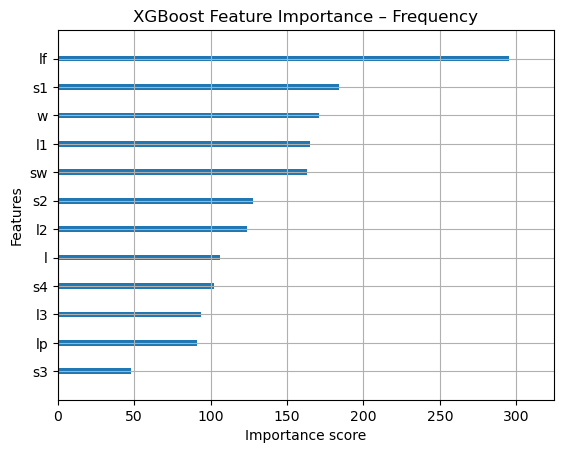

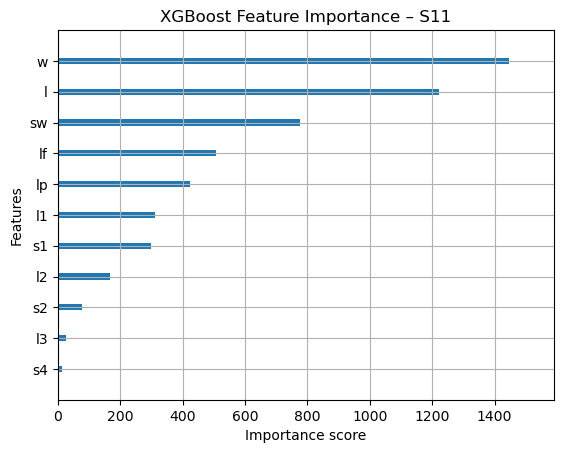

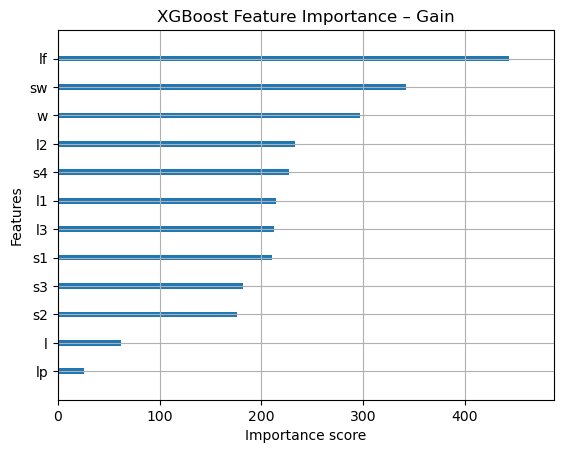

In [11]:
## 10. Feature Importance Analysis using XGBoost
xgb.plot_importance(freq_model, importance_type='weight', show_values=False)
plt.title("XGBoost Feature Importance – Frequency")
plt.show()

xgb.plot_importance(s11_model, importance_type='weight', show_values=False)
plt.title("XGBoost Feature Importance – S11")
plt.show()

xgb.plot_importance(gain_model, importance_type='weight', show_values=False)
plt.title("XGBoost Feature Importance – Gain")
plt.show()

In [12]:
## 11. User Input and Prediction using XGBoost Models
print("\nEnter Antenna Parameters:")

Lp = float(input("Enter Patch Length Lp (mm): "))
Lf = float(input("Enter Feed Length Lf (mm): "))
Sw = float(input("Enter Stub Height Sw (mm): "))

L1 = float(input("Enter Director Length L1 (mm): "))
L2 = float(input("Enter Director Length L2 (mm): "))
L3 = float(input("Enter Director Length L3 (mm): "))
L4 = float(input("Enter Director Length L4 (mm): "))

s1 = float(input("Enter Director Spacing s1 (mm): "))
s2 = float(input("Enter Director Spacing s2 (mm): "))
s3 = float(input("Enter Director Spacing s3 (mm): "))
s4 = float(input("Enter Director Spacing s4 (mm): "))

L = float(input("Enter Substrate Length l (mm): "))
W = float(input("Enter Substrate Width w (mm): "))

user_input = pd.DataFrame(
    [[Lp, Lf, Sw, L1, L2, L3, L4, s1, s2, s3, s4, L, W]],
    columns=X.columns
)

print("\n--- XGBoost Prediction Results ---")
print(f"Resonant Frequency : {freq_model.predict(user_input)[0]:.4f} GHz")
print(f"Minimum S11        : {s11_model.predict(user_input)[0]:.4f} dB")
print(f"Gain               : {gain_model.predict(user_input)[0]:.4f} dBi")


Enter Antenna Parameters:


Enter Patch Length Lp (mm):  31
Enter Feed Length Lf (mm):  34
Enter Stub Height Sw (mm):  2.8
Enter Director Length L1 (mm):  24
Enter Director Length L2 (mm):  18
Enter Director Length L3 (mm):  12
Enter Director Length L4 (mm):  14
Enter Director Spacing s1 (mm):  2.2
Enter Director Spacing s2 (mm):  2
Enter Director Spacing s3 (mm):  1.89
Enter Director Spacing s4 (mm):  2.2
Enter Substrate Length l (mm):  65
Enter Substrate Width w (mm):  55



--- XGBoost Prediction Results ---
Resonant Frequency : 1.9747 GHz
Minimum S11        : -17.7433 dB
Gain               : 1.5105 dBi
